<a href="https://colab.research.google.com/github/Karthik-S-Ballal/Data-Analytics-Course/blob/DA-ANLP/worksheet/02_Recurrent_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recurrent Neural Networks

In other tasks, such as computer vision images can be scaled to a fixed size. However, in NLP, the input can be of variable length.

- Sequence models are deep learning models that are used for **time series** data or **sequential** data.
- Examples:
  - Speech recognition
  - Music generation
  - Sentiment classification
  - DNA sequence analysis
  - Machine translation
  - Video activity recognition
  - Name entity recognition
  - ...

- Notation:
  - $x^{t}$: Input at time $t$.
  - $h^{t}$: Hidden state at time $t$.
  - $y^{t}$: Output at time $t$.

$$ h^{t} = f(h^{t-1}, x^{t}) $$

$$ y^{t} = g(h^{t}) $$


We can use the same weights for every time step.

$$ h^{t} = f(h^{t-1}, x^{t}; \mathbf{W}) $$

$$ y^{t} = g(h^{t}; \mathbf{W}) $$


$$ y_i = f(\mathbf{W}_{hy} h_i + b_y) $$

$$ h_i = g(\mathbf{W}_{hh} h_{i-1} + \mathbf{W}_{xh} x_i + b_h) $$

Initially, $h_0$ is set to zero. $f$ and $g$ are non-linear activation functions.

Let's implement this in PyTorch

In [ ]:
# A simple PyTorch module looks like this
import torch.nn as nn
import torch.nn.functional as F
import torch

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(20, 2)

    def forward(self, x):
        return F.relu(self.linear(x))

We will implement a recurrent neural network together.

In [ ]:
class SimpleRNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.hidden1 = nn.Linear(input_size, hidden_size)
    self.hidden2 = nn.Linear(hidden_size, hidden_size)
    self.output = nn.Linear(hidden_size, output_size)
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size

  def forward(self, x):
    n = x.shape[0]
    y = torch.zeros(n, self.output_size)
    h = torch.zeros(self.hidden_size)

    for i in range(n):
      h = F.relu(self.hidden1(x[i]) + self.hidden2(h))
      y[i] = F.sigmoid(self.output(h))

    return y


In [ ]:
# Some simple code to test this

X = torch.rand(5, 10)
rnn = SimpleRNN(10, 8, 2)
rnn(X)

tensor([[0.5049, 0.5906],
        [0.4970, 0.6102],
        [0.4968, 0.5994],
        [0.5028, 0.6178],
        [0.5006, 0.5876]], grad_fn=<CopySlices>)


## RNNs for tagging

- Input: a sequence of words $x_1, \ldots, x_n$.
- Output: a sequence of tags $y_1, \ldots, y_n$.

The output can be computed directly using a softmax layer.


Let's train our model to do part of speech tagging

We will do part-of-speech tagging from the Brown corpus. To simplify this, we will only use the first letter of the POS tag (as there are about ~500 different tags in the corpus).

In [ ]:
import nltk
nltk.download("brown")
from nltk.corpus import brown

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


In [ ]:
# Use a simplified tagset
tags = list(set(tag[0:1] for (_, tag) in brown.tagged_words()))
print(len(tags))

28


In [ ]:
# Create a random embedding
words = list(set(w.lower() for (w, _) in brown.tagged_words()))
embeddings = torch.rand(len(words), 10)

In [ ]:
# Train the model
model = SimpleRNN(10,10,len(tags))

def train_model(model):
  optim = torch.optim.Adam(model.parameters(), lr=0.01)

  loss_fn = nn.CrossEntropyLoss()

  losses = []

  for sent in brown.tagged_sents()[:100]:
    n = len(sent)
    X = torch.zeros(n, 10)
    y = torch.zeros(n, len(tags))

    for i in range(n):
      X[i,:] = embeddings[words.index(sent[i][0].lower())]
      y[i,tags.index(sent[i][1][0:1])] = 1

    pred = model(X)
    loss = loss_fn(y, pred)
    losses.append(loss.item())
    # TODO
    optim.zero_grad()
    loss.backward()
    optim.step()
  return losses

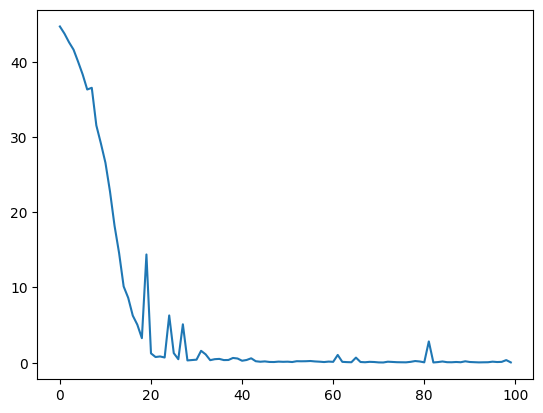

In [ ]:
# Plot the loss
import matplotlib.pyplot as plt
plt.plot(train_model(model))


## RNNs for language modeling

- Input: a sequence of words $x_1, \ldots, x_n$.
- Output: the probability of the next word $x_{n+1}$.

Again a softmax output layer can be used to compute the probability distribution.


## RNNs for classification (acceptor)

Simple use of an RNN is as an acceptor. The final state of the RNN is used to classify the input sequence.

$$ y = f(\mathbf{W}_{hy} h_n + b_y) $$

No prediction is made for other time steps.

## RNNs for classification (attention)

Instead of discarding the hidden states, we can use them to compute a weighted sum of the hidden states.

$$ y = f(\sum_{i=1}^n \alpha_i h_i) $$

$$ \alpha_i = \frac{\exp(\mathbf{w}_{\alpha}^T h_i)}{\sum_{j=1}^n \exp(\mathbf{w}_{\alpha}^T h_j)} $$




## Bidirectional RNNs

- In some cases, we want to use information from the future.
- We can use a bidirectional RNN to do this.
- The hidden state is computed from both the past and the future.


$$ \overrightarrow{h}_i = f(\mathbf{W}_{\overrightarrow{hh}} \overrightarrow{h}_{i-1} + \mathbf{W}_{\overrightarrow{xh}} x_i + b_{\overrightarrow{h}}) $$

$$ \overleftarrow{h}_i = f(\mathbf{W}_{\overleftarrow{hh}} \overleftarrow{h}_{i+1} + \mathbf{W}_{\overleftarrow{xh}} x_i + b_{\overleftarrow{h}}) $$

$$ h_i = (\overrightarrow{h}_i  \overleftarrow{h}_i) $$



**Can you create a bidirectional RNN from our `SimpleRNN`?**

In [ ]:
class SimpleBiRNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.output = []
    self.hidden = []
    self.hidden_size = hidden_size
    self.output_size = output_size

  def forward(self, x):
    n = x.shape[0]
    h = torch.zeros(self.hidden_size)
    y = torch.zeros(n, self.output_size)

    for i in range(n):
      pass

    return y


## Backpropagation through time

- Gradients in a RNN are harder to compute than in a feedforward network.
- This is because the same weights are used at each time step.
- The gradients are summed over time steps.

### Vanishing gradients

- The gradients can become very small.
- This is because the gradients are multiplied by the same weights at each time step.
- This is called the vanishing gradient problem.

### Exploding gradients

- Alternatively, the gradients can become very large (exploding gradients).
- One way to deal with exploding gradients is to clip the gradients.
- If the gradient norm is larger than a threshold, the gradients are scaled down.

Let's try to calculate this simple system

$$
\mathcal{L} = \mathcal{l}(h_n)
$$

$$
h_n = f(a h_{n-1} + x)
$$

Assume that all values are 1-dimensional (scalar). For $n=3$ what is $\frac{\partial \mathcal{L}}{\partial a}$?


$$
\frac{\partial \mathcal{L}}{\partial a} = ?
$$

Consider the derivate of $\sigma(x)$

https://www.wolframalpha.com/input?i=d%2Fdx+sigmoid%28x%29

Do you think that this gradient will vanish or explode if $f(x) = \sigma(x)$?


## Gating

- Gating is a way to control the flow of information in a RNN.
- Gating can be used to deal with the vanishing gradient problem.

- A gate is a function that takes two inputs and produces an output.
- The output is the pairwise product of the inputs.

$$ \mathbf{g} = \mathbf{x} \odot \mathbf{y} $$

### Gated Recurrent Unit (GRU)

- The GRU is a gated RNN.
- It has two gates: an update gate and a reset gate.
- The update gate controls how much of the previous state is kept.
- The reset gate controls how much of the previous state is forgotten.

### Long Short-Term Memory (LSTM)

- The LSTM is a more complex gated RNN.
- It has three gates: an input gate, an output gate and a forget gate.
- The input gate controls how much of the input is kept.
- The output gate controls how much of the state is output.
- The forget gate controls how much of the state is forgotten.

- In practice, GRUs and LSTMs perform similarly.
- GRUs are simpler and faster to train.
- LSTMs are more flexible and can be used in more complex situations.


Let's implement a better part-of-speech classifier using PyTorch's built-ins:

https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html

https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html

https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader

In [ ]:
class LSTMTagger(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, word_count):
    super().__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size

  def forward(self, x):
    pass

We will use an embedding layer, so we need to change the form of our tokens.

We will also switch to using minibatches of 5 sentences

In [ ]:
from torch.utils.data import DataLoader, Dataset

class SentenceDataset(Dataset):
  def __init__(self, sents, words, tags):
    self.sents = list(sents)
    self.word_idx = {w.lower():(i+1) for (i,w) in enumerate(words)}
    self.tag_idx = {t:(i+1) for (i, t) in enumerate(tags)}
    self.max_len = max(len(sent) for sent in sents)

  def __len__(self):
    return len(self.sents)

  def __getitem__(self, idx):
    sent = self.sents[idx]
    words = torch.tensor([self.word_idx[w.lower()] for (w,t) in sent] + [0] * (self.max_len - len(sent)))
    tags = torch.zeros(self.max_len, len(self.tag_idx)+1)
    for i, (_, t) in enumerate(sent):
      tags[i, self.tag_idx[t[0]]] = 1
    return words, tags

dataset = SentenceDataset(brown.tagged_sents()[:5000], words, tags)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [ ]:
def train_model(model):
  optim = torch.optim.Adam(model.parameters(), lr=0.01)

  loss_fn = torch.nn.CrossEntropyLoss()

  losses = []

  for j, (X, Y) in enumerate(loader):
    output = model(X)
    loss = loss_fn(Y, output)
    losses.append(loss.item())
    optim.zero_grad()
    loss.backward()
    optim.step()
  return losses

In [ ]:
losses = train_model(LSTMTagger(10,11,len(tags)+1, len(words)))
plt.plot(losses)